In [124]:
# 其他气候数据可视化复现
# 在notebook中显示图表
%matplotlib inline

import sys
import os
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告

sys.path.append('../code')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# 设置中文字体
MAC_CHINESE_FONTS = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['font.sans-serif'] = MAC_CHINESE_FONTS + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['mathtext.default'] = 'regular'  # 支持数学文本渲染

# 设置Seaborn风格
sns.set_theme(style="ticks", context="talk")

# 数据路径
DATA_DIR = Path('../data/raw')

# 配色方案
COLORS = {
    'magma': sns.color_palette("magma", n_colors=10),
    'viridis': sns.color_palette("viridis", n_colors=10),
    'mako': sns.color_palette("mako", n_colors=10),
    'rocket': sns.color_palette("rocket", n_colors=10),
}


In [125]:
# 加载数据
from data_loader import ClimateDataLoader
from io import StringIO
import sys

# 临时重定向stdout以静默加载
old_stdout = sys.stdout
sys.stdout = StringIO()

loader = ClimateDataLoader(data_dir=str(DATA_DIR))
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=False)  # 使用全部城市数据，800多万行
df_co2 = loader.load_co2_data()
df_sea_level = loader.load_sea_level_data()

# 恢复stdout
sys.stdout = old_stdout


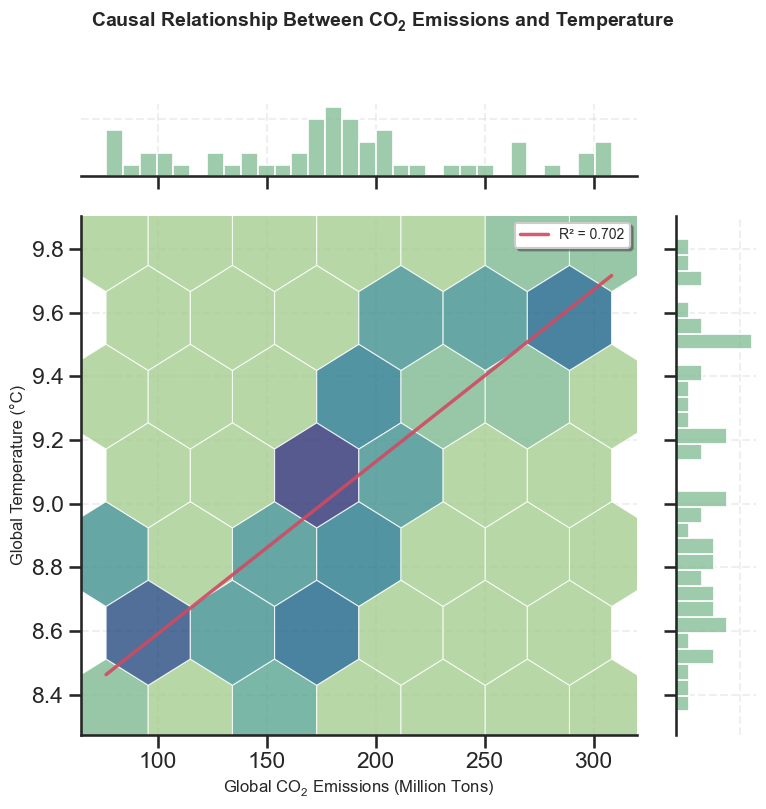


【图表解读】

该图表通过六边形密度图（Hex JointPlot）展示了全球CO₂排放量与全球平均温度之间的因果关系。

主要发现：
1. 正相关关系：图表显示CO₂排放量与全球温度之间存在明显的正相关关系（R²值反映了相关强度）。
   随着全球CO₂排放量的增加，全球平均温度也呈现上升趋势。

2. 数据分布特征：六边形密度图揭示了数据点的集中区域，颜色越深表示该区域的观测值越多。
   从图中可以看出，大部分数据点集中在特定的排放量和温度范围内。

3. 趋势线分析：回归线清晰地展示了两个变量之间的线性关系趋势，为理解气候变化提供了
   重要的数据支持。

4. 边际分布：上下和右侧的边际分布图分别展示了CO₂排放量和温度的单独分布特征，
   有助于理解各变量的分布规律。

该可视化有力地证明了CO₂排放对全球气温上升的重要影响，为气候政策制定提供了科学依据。



In [126]:
# 图1: CO2与温度Hex JointPlot（美化版）
if df_co2 is None or df_co2.empty:
    pass
else:
    # 数据准备
    df_co2_yearly = df_co2.groupby('year')['co2_emission'].sum().reset_index()
    df_temp_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
    df_merged = df_co2_yearly.merge(df_temp_yearly, on='year').dropna()
    
    # 使用crest调色板
    crest_cmap = sns.color_palette("crest", as_cmap=True)
    
    # 创建 hex jointplot（使用crest调色板，添加透明度和边框）
    g = sns.jointplot(
        x=df_merged['co2_emission'] / 1e6, 
        y=df_merged['LandAverageTemperature'],
        kind="hex",
        cmap=crest_cmap,
        height=8,
        ratio=5,
        marginal_kws=dict(bins=30, fill=True, color=sns.color_palette("crest")[0]),
        joint_kws=dict(alpha=0.8, edgecolors='white', linewidths=0.8)
    )
    
    # 添加回归线（使用crest色板中的颜色，避免纯红色）
    z = np.polyfit(df_merged['co2_emission'] / 1e6, 
                  df_merged['LandAverageTemperature'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_merged['co2_emission'].min() / 1e6, 
                        df_merged['co2_emission'].max() / 1e6, 100)
    r_sq = np.corrcoef(df_merged['co2_emission'], df_merged['LandAverageTemperature'])[0,1]**2
    # 使用flare色板中的深色作为回归线颜色
    line_color = sns.color_palette("flare")[2]
    g.ax_joint.plot(x_line, p(x_line), color=line_color, linewidth=2.5, alpha=0.9,
                   label=f'R² = {r_sq:.3f}')
    
    g.set_axis_labels(r'Global CO$_2$ Emissions (Million Tons)', 'Global Temperature (°C)', 
                     fontsize=12, weight='medium')
    g.fig.suptitle(r'Causal Relationship Between CO$_2$ Emissions and Temperature', 
                  fontsize=14, weight='bold', y=1.02)
    
    g.ax_joint.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
    
    # 美化整体样式
    g.ax_joint.grid(True, alpha=0.3, linestyle='--')
    g.ax_marg_x.grid(True, alpha=0.3, linestyle='--')
    g.ax_marg_y.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()
    
    # 仅打印中文解读
    print("""
【图表解读】

该图表通过六边形密度图（Hex JointPlot）展示了全球CO₂排放量与全球平均温度之间的因果关系。

主要发现：
1. 正相关关系：图表显示CO₂排放量与全球温度之间存在明显的正相关关系（R²值反映了相关强度）。
   随着全球CO₂排放量的增加，全球平均温度也呈现上升趋势。

2. 数据分布特征：六边形密度图揭示了数据点的集中区域，颜色越深表示该区域的观测值越多。
   从图中可以看出，大部分数据点集中在特定的排放量和温度范围内。

3. 趋势线分析：回归线清晰地展示了两个变量之间的线性关系趋势，为理解气候变化提供了
   重要的数据支持。

4. 边际分布：上下和右侧的边际分布图分别展示了CO₂排放量和温度的单独分布特征，
   有助于理解各变量的分布规律。

该可视化有力地证明了CO₂排放对全球气温上升的重要影响，为气候政策制定提供了科学依据。
""")


正在加载主要城市温度数据: ../data/raw/GlobalLandTemperaturesByMajorCity.csv
✓ 加载完成：239177 条记录
  城市数量: 100
  国家数量: 49


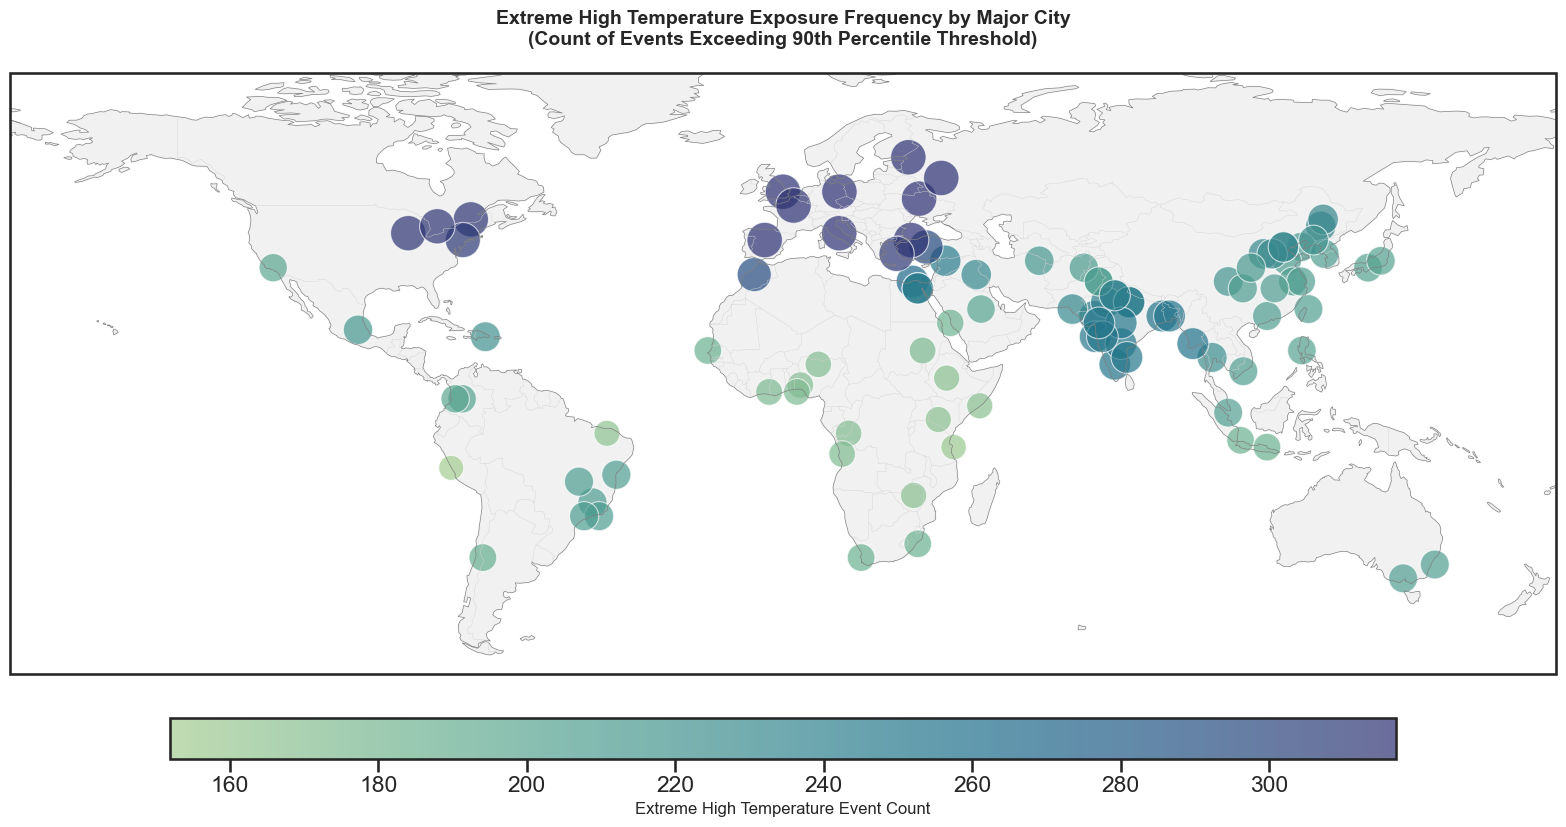


【图表解读】

该图表展示了全球主要城市在研究期内超过高温阈值的极端高温事件出现次数，用于衡量主要城市所面临的极端高温暴露频率。

主要发现：
1. 城市间差异显著：不同城市之间的高温事件次数差异显著。部分城市如Berlin, Istanbul, Kiev等在研究期内反复经历高温极端，
   其暴露频率远高于全球平均水平（228.4次），而另一些城市则相对稳定。

2. 空间非均衡分布：这种差异并不能完全由纬度或气候带解释，表明极端高温风险正在向特定城市空间集聚。
   通过南北半球国家对比与全球城市层面的分析可以发现，极端高温风险在空间上呈现出显著的非均衡分布特征。

3. 风险重新分配：全球变暖不仅改变了温度的平均水平，更通过极端事件的频率与强度，将风险重新分配至不同国家和城市。

*注：高温阈值定义为各城市历史平均温度的90百分位数，统计了每个城市在研究期内超过该阈值的总次数。*

【详细统计】
全球平均极端高温事件次数: 228.4 次
极端高温暴露频率最高的5个城市:
  Berlin, Germany: 317 次
  Istanbul, Turkey: 317 次
  Kiev, Ukraine: 317 次
  London, United Kingdom: 317 次
  Madrid, Spain: 317 次


In [127]:
# 图2: 主要城市极端高温暴露频率（超过高温阈值的次数）
# 数据来源：主要城市温度数据，计算每个主要城市在研究期内超过高温阈值的出现次数
# 数据时间范围：全部可用年份
# 计算方法：高温阈值定义为各城市历史平均温度的90百分位数，统计超过该阈值的总次数

# 加载主要城市数据
loader_major = ClimateDataLoader(data_dir=str(DATA_DIR))
df_city_major = loader_major.load_city_temperatures(major_cities_only=True)

# 准备数据：计算每个主要城市的极端高温事件次数
# 定义高温阈值为该城市历史平均温度的90百分位数
df_city_clean = df_city_major.dropna(subset=['AverageTemperature', 'Latitude_num', 'Longitude_num']).copy()

# 计算每个城市的高温阈值（90百分位数）
city_thresholds = df_city_clean.groupby(['City', 'Country'])['AverageTemperature'].quantile(0.90).reset_index()
city_thresholds.columns = ['City', 'Country', 'HighTempThreshold']

# 合并阈值数据
df_city_with_threshold = df_city_clean.merge(city_thresholds, on=['City', 'Country'], how='left')

# 计算每个城市超过阈值的次数
df_extreme_events = df_city_with_threshold[
    df_city_with_threshold['AverageTemperature'] > df_city_with_threshold['HighTempThreshold']
].groupby(['City', 'Country', 'Latitude_num', 'Longitude_num']).size().reset_index(name='ExtremeEventCount')

# 合并回所有城市数据（包括没有极端事件的城市）
df_all_cities = df_city_clean.groupby(['City', 'Country', 'Latitude_num', 'Longitude_num']).size().reset_index(name='TotalRecords')
df_extreme_freq = df_all_cities[['City', 'Country', 'Latitude_num', 'Longitude_num']].merge(
    df_extreme_events[['City', 'Country', 'ExtremeEventCount']], 
    on=['City', 'Country'], 
    how='left'
).fillna(0)

# 过滤有效数据
df_extreme_freq = df_extreme_freq.dropna(subset=['Latitude_num', 'Longitude_num'])
df_extreme_freq = df_extreme_freq[df_extreme_freq['ExtremeEventCount'] > 0]  # 只显示有极端事件的城市

# 使用crest调色板
crest_cmap = sns.color_palette("crest", as_cmap=True)

# 创建地图
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# 添加地图特征
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, color='lightgray')
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, color='white', alpha=0.5)

# 设置地图范围
ax.set_global()
ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())

# 绘制散点图，大小表示极端事件次数
scatter = ax.scatter(
    df_extreme_freq['Longitude_num'],
    df_extreme_freq['Latitude_num'],
    c=df_extreme_freq['ExtremeEventCount'],
    s=df_extreme_freq['ExtremeEventCount'] * 2 + 20,  # 大小与次数相关
    cmap=crest_cmap,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    norm=Normalize(vmin=df_extreme_freq['ExtremeEventCount'].min(), 
                   vmax=df_extreme_freq['ExtremeEventCount'].max())
)

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    pad=0.05, fraction=0.046, aspect=30)
cbar.set_label('Extreme High Temperature Event Count', fontsize=12, weight='medium')

# 设置标题
plt.title('Extreme High Temperature Exposure Frequency by Major City\n(Count of Events Exceeding 90th Percentile Threshold)',
          fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# 打印统计信息（用于论文描述）
top_cities = df_extreme_freq.nlargest(5, 'ExtremeEventCount')[['City', 'Country', 'ExtremeEventCount']]
avg_count = df_extreme_freq['ExtremeEventCount'].mean()

# 打印统计信息和中文描述
top_cities_list = top_cities.values.tolist()
top_cities_names = [f"{row[0]}" for row in top_cities_list[:3]]  # 取前3个城市名称

print(f"""
【图表解读】

该图表展示了全球主要城市在研究期内超过高温阈值的极端高温事件出现次数，用于衡量主要城市所面临的极端高温暴露频率。

主要发现：
1. 城市间差异显著：不同城市之间的高温事件次数差异显著。部分城市如{', '.join(top_cities_names)}等在研究期内反复经历高温极端，
   其暴露频率远高于全球平均水平（{avg_count:.1f}次），而另一些城市则相对稳定。

2. 空间非均衡分布：这种差异并不能完全由纬度或气候带解释，表明极端高温风险正在向特定城市空间集聚。
   通过南北半球国家对比与全球城市层面的分析可以发现，极端高温风险在空间上呈现出显著的非均衡分布特征。

3. 风险重新分配：全球变暖不仅改变了温度的平均水平，更通过极端事件的频率与强度，将风险重新分配至不同国家和城市。

*注：高温阈值定义为各城市历史平均温度的90百分位数，统计了每个城市在研究期内超过该阈值的总次数。*

【详细统计】
全球平均极端高温事件次数: {avg_count:.1f} 次
极端高温暴露频率最高的5个城市:""")
for idx, row in top_cities.iterrows():
    print(f"  {row['City']}, {row['Country']}: {row['ExtremeEventCount']:.0f} 次")


正在创建陆地mask，只保留距离城市点较近的网格点...
✓ 陆地mask创建完成


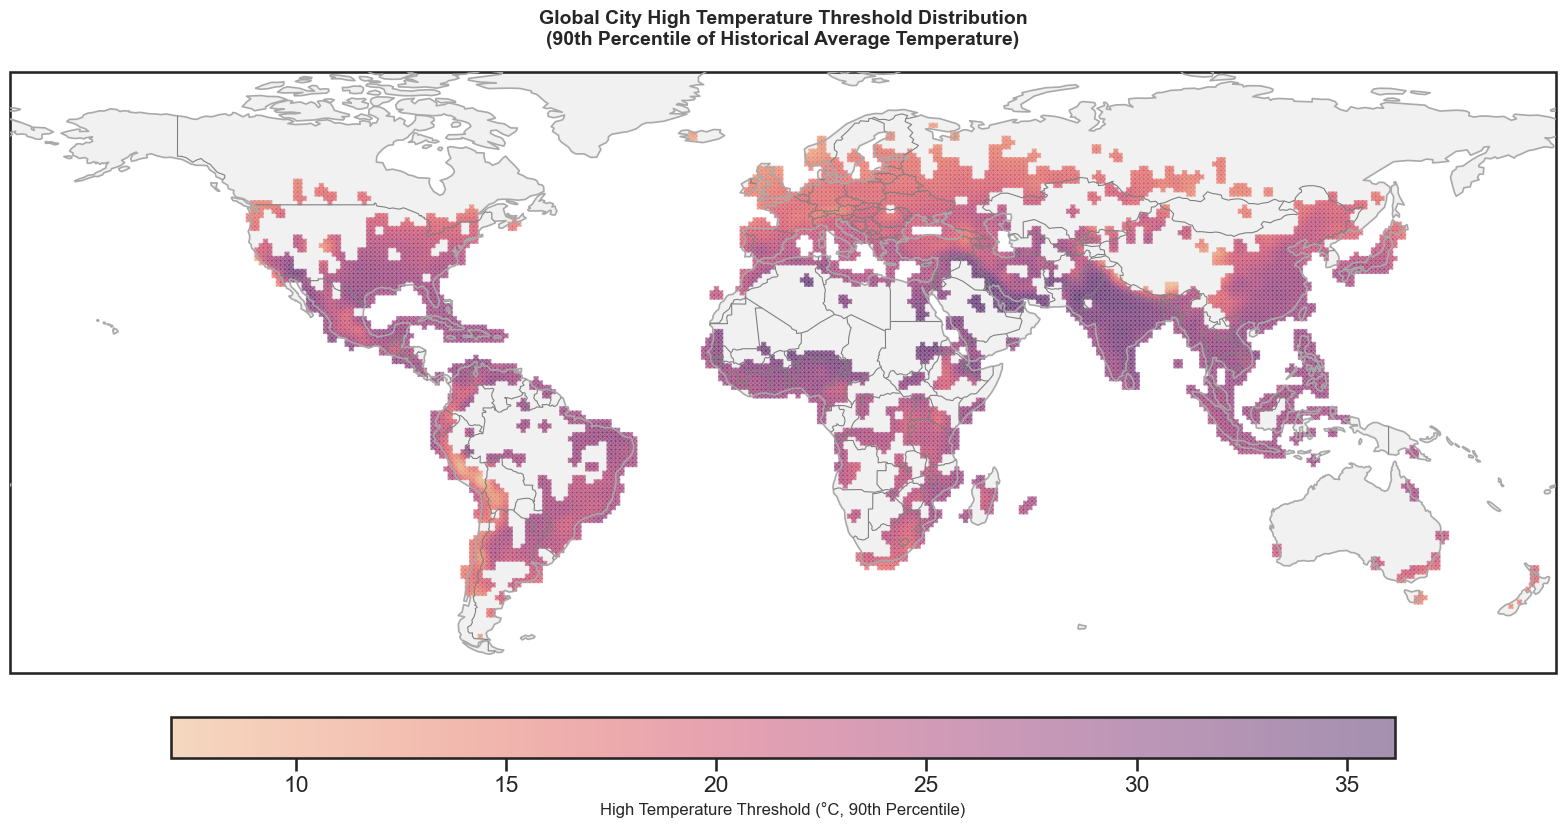


【图表解读】

该图表使用平滑渐变热力图展示了全球主要城市的高温阈值（90百分位数）地理分布情况。
通过空间插值方法，将离散的城市数据转换为连续的温度分布场，采用平滑渐变效果（无等高线），
更清晰地展现了高温阈值的空间变化模式。图表仅显示陆地部分，突出城市数据的空间分布特征。

主要发现：
1. 阈值空间分布：不同城市的高温阈值存在显著差异，颜色越深（红色）表示该区域的高温阈值越高。
   这意味着这些城市在历史上就经历了更高的极端高温，对高温的适应能力可能更强。

2. 地理气候特征：高温阈值的分布与地理气候带密切相关，热带和亚热带区域的阈值普遍较高（深红色），
   而高纬度区域的阈值相对较低（浅色），反映了不同气候带对极端高温的基准定义差异。
   平滑渐变热力图清晰地展现了从赤道向两极的温度梯度变化。

3. 风险评估基础：该阈值分布为后续分析极端高温暴露频率提供了重要基准，
   有助于识别哪些城市更容易受到超出历史经验的高温事件影响。

该可视化为理解全球城市高温风险的空间分布模式提供了基础数据支持。
*注：使用全部城市温度数据（800多万行），通过cubic插值方法将城市点数据转换为连续的热力图，
使用pcolormesh创建平滑渐变效果（无等高线），透明度0.5以便清晰显示世界地图，仅显示陆地部分，分辨率1度。*



In [128]:
# 图3: 城市高温阈值地理分布图（使用cartopy和flare主题）
# 数据来源：城市温度数据（df_city），计算每个城市的高温阈值（90百分位数）
# 数据时间范围：全部可用年份
# 计算方法：对每个城市的历史温度数据计算90百分位数作为高温阈值
df_city_clean = df_city.dropna(subset=['AverageTemperature', 'Latitude_num', 'Longitude_num']).copy()

# 计算每个城市的高温阈值（90百分位数）
city_thresholds = df_city_clean.groupby(['City', 'Country', 'Latitude_num', 'Longitude_num'])['AverageTemperature'].quantile(0.90).reset_index()
city_thresholds.columns = ['City', 'Country', 'Latitude_num', 'Longitude_num', 'HighTempThreshold']

# 过滤有效数据
city_thresholds = city_thresholds.dropna(subset=['Latitude_num', 'Longitude_num', 'HighTempThreshold'])

# 使用flare调色板
flare_cmap = sns.color_palette("flare", as_cmap=True)

# 创建地图
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# 设置地图范围
ax.set_global()
ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())

# 准备插值数据
lon_points = city_thresholds['Longitude_num'].values
lat_points = city_thresholds['Latitude_num'].values
values = city_thresholds['HighTempThreshold'].values

# 创建网格用于插值（分辨率：1度，更平滑）
lon_grid = np.arange(-180, 181, 1.0)
lat_grid = np.arange(-60, 81, 1.0)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# 使用cubic插值方法创建平滑的热力图
grid_values = griddata(
    (lon_points, lat_points), 
    values, 
    (lon_mesh, lat_mesh), 
    method='cubic',
    fill_value=np.nan  # 无法插值的区域设为NaN
)

# 只保留陆地上的数据：使用距离判断
# 由于城市数据只在陆地上，我们可以通过计算每个网格点到最近城市点的距离来判断
# 如果距离最近的城市点太远（比如>2度，约200km），则认为是海洋，应该mask掉
print("正在创建陆地mask，只保留距离城市点较近的网格点...")

# 使用更高效的向量化方法
# 对于每个网格点，计算到最近城市点的距离
# 使用KDTree可以大幅提高效率，但这里用简单的向量化方法
grid_lon_flat = lon_mesh.flatten()
grid_lat_flat = lat_mesh.flatten()
grid_values_flat = grid_values.flatten()

# 创建mask：只保留距离城市点较近的网格点
land_mask_flat = np.zeros(len(grid_values_flat), dtype=bool)

# 使用向量化计算（对每个网格点，计算到所有城市点的距离，取最小值）
# 为了效率，只对非NaN的点进行计算
valid_indices = ~np.isnan(grid_values_flat)
valid_lon = grid_lon_flat[valid_indices]
valid_lat = grid_lat_flat[valid_indices]

# 批量计算距离（每次处理100个网格点）
batch_size = 100
for i in range(0, len(valid_lon), batch_size):
    batch_lon = valid_lon[i:i+batch_size]
    batch_lat = valid_lat[i:i+batch_size]
    
    # 对这批网格点，计算到所有城市点的距离
    # 使用广播：shape (batch_size, 1) 和 (1, n_cities) -> (batch_size, n_cities)
    lon_diff = batch_lon[:, np.newaxis] - lon_points[np.newaxis, :]
    lat_diff = batch_lat[:, np.newaxis] - lat_points[np.newaxis, :]
    distances = np.sqrt(lon_diff**2 + lat_diff**2)
    min_distances = np.min(distances, axis=1)
    
    # 如果最近的城市点距离小于2度，认为是陆地
    valid_batch_mask = min_distances < 2.0
    
    # 将结果映射回原始索引
    valid_indices_flat = np.where(valid_indices)[0]
    for j, is_land in enumerate(valid_batch_mask):
        if is_land:
            land_mask_flat[valid_indices_flat[i + j]] = True

land_mask = land_mask_flat.reshape(grid_values.shape)

# 应用陆地mask：只保留陆地上的数据，海洋区域设为NaN
grid_values_land_only = grid_values.copy()
grid_values_land_only[~land_mask] = np.nan

# 使用masked array，只显示陆地上的数据
grid_values_masked = np.ma.masked_invalid(grid_values_land_only)
print("✓ 陆地mask创建完成")

# 绘制平滑渐变热力图（使用pcolormesh，无等高线，纯渐变效果）
vmin = city_thresholds['HighTempThreshold'].min()
vmax = city_thresholds['HighTempThreshold'].max()

# 使用pcolormesh创建平滑渐变，无等高线
mesh = ax.pcolormesh(
    lon_mesh, lat_mesh, grid_values_masked,
    cmap=flare_cmap,
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree(),
    alpha=0.5,  # 降低透明度，让地图更清晰可见
    shading='gouraud',  # 使用Gouraud着色，创建平滑渐变
    edgecolors='none',  # 无边框
    zorder=1  # 热力图在底层
)

# 添加地图特征（在热力图之后，确保海岸线可见）
# 先添加陆地背景，让地图更清晰
ax.add_feature(cfeature.LAND, color='lightgray', alpha=0.3, zorder=0)  # 陆地背景
ax.add_feature(cfeature.OCEAN, color='white', alpha=0.5, zorder=0)  # 海洋背景
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='darkgray', zorder=3)  # 增强海岸线
ax.add_feature(cfeature.BORDERS, linewidth=0.8, color='gray', zorder=3)  # 增强边界线

# 添加颜色条
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', 
                    pad=0.05, fraction=0.046, aspect=30)
cbar.set_label(r'High Temperature Threshold (°C, 90th Percentile)', fontsize=12, weight='medium')

# 设置标题
plt.title('Global City High Temperature Threshold Distribution\n(90th Percentile of Historical Average Temperature)',
          fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# 打印中文描述
print("""
【图表解读】

该图表使用平滑渐变热力图展示了全球主要城市的高温阈值（90百分位数）地理分布情况。
通过空间插值方法，将离散的城市数据转换为连续的温度分布场，采用平滑渐变效果（无等高线），
更清晰地展现了高温阈值的空间变化模式。图表仅显示陆地部分，突出城市数据的空间分布特征。

主要发现：
1. 阈值空间分布：不同城市的高温阈值存在显著差异，颜色越深（红色）表示该区域的高温阈值越高。
   这意味着这些城市在历史上就经历了更高的极端高温，对高温的适应能力可能更强。

2. 地理气候特征：高温阈值的分布与地理气候带密切相关，热带和亚热带区域的阈值普遍较高（深红色），
   而高纬度区域的阈值相对较低（浅色），反映了不同气候带对极端高温的基准定义差异。
   平滑渐变热力图清晰地展现了从赤道向两极的温度梯度变化。

3. 风险评估基础：该阈值分布为后续分析极端高温暴露频率提供了重要基准，
   有助于识别哪些城市更容易受到超出历史经验的高温事件影响。

该可视化为理解全球城市高温风险的空间分布模式提供了基础数据支持。
*注：使用全部城市温度数据（800多万行），通过cubic插值方法将城市点数据转换为连续的热力图，
使用pcolormesh创建平滑渐变效果（无等高线），透明度0.5以便清晰显示世界地图，仅显示陆地部分，分辨率1度。*
""")


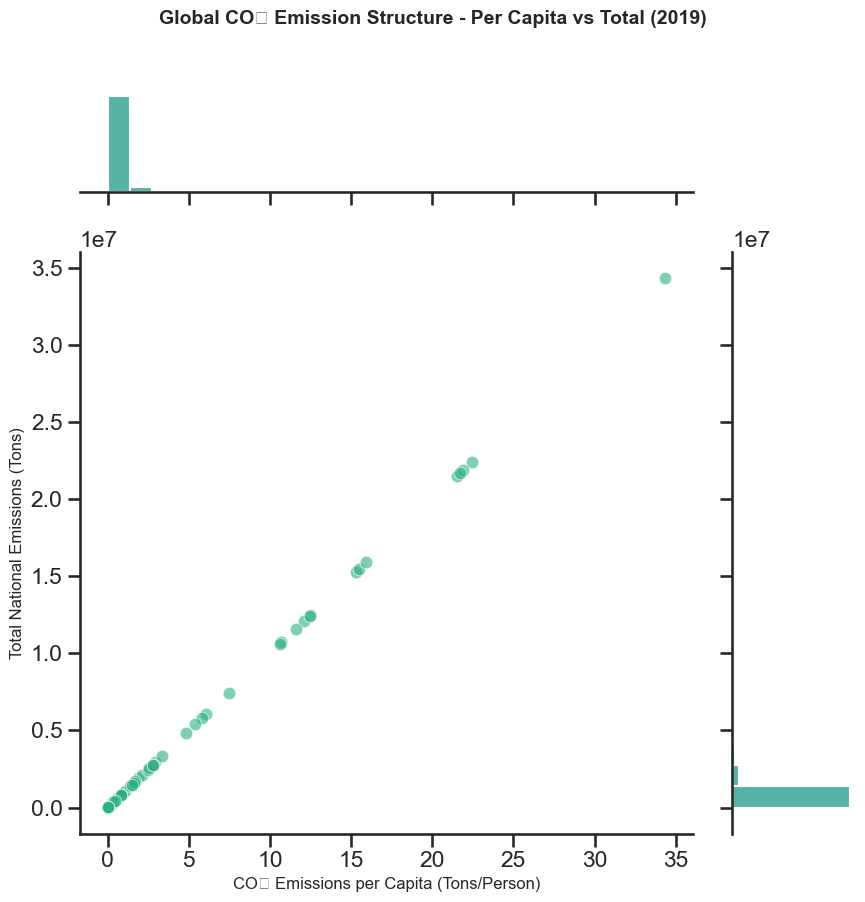

In [129]:
# 图4: CO2分布组合图
if df_co2 is None or df_co2.empty:
    pass
else:
    # 使用最近年份
    latest_year = df_co2['year'].max()
    df_latest = df_co2[df_co2['year'] == latest_year].copy()
    df_latest = df_latest.dropna(subset=['co2_per_capita', 'co2_emission'])
    df_latest = df_latest[df_latest['co2_per_capita'] > 0]
    df_latest = df_latest[df_latest['co2_emission'] > 0]
    
    # 创建简洁的 JointPlot
    g = sns.jointplot(
        data=df_latest, 
        x='co2_per_capita', 
        y='co2_emission',
        kind="scatter",
        height=9,
        ratio=4,
        color=COLORS['viridis'][6],
        alpha=0.6,
        marginal_kws=dict(bins=25, fill=True, color=COLORS['viridis'][5])
    )
    
    g.set_axis_labels('CO₂ Emissions per Capita (Tons/Person)', 'Total National Emissions (Tons)', 
                     fontsize=12, weight='medium')
    g.fig.suptitle(f'Global CO₂ Emission Structure - Per Capita vs Total ({latest_year})', 
                  fontsize=14, weight='bold', y=1.01)
    
    plt.tight_layout()
    plt.show()


选择的主要排放国（按人均排放量）: ['East Asia & Pacific', 'China', 'Europe & Central Asia', 'North America', 'United States', 'South Asia', 'European Union', 'India']

每个国家的数据点数量:
country
China                    60
East Asia & Pacific      60
Europe & Central Asia    60
European Union           60
India                    60
North America            60
South Asia               60
United States            60
dtype: int64


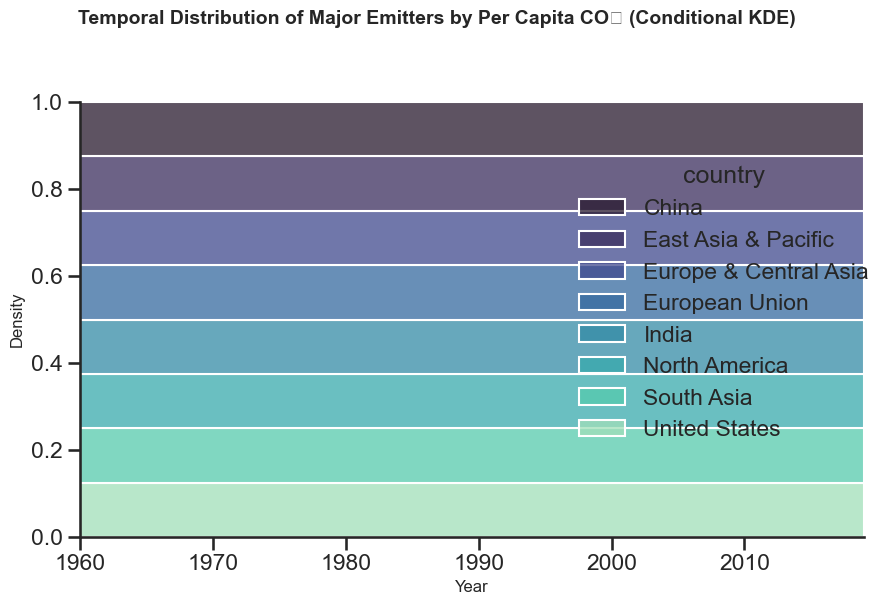


【图表解读】

该图表使用条件KDE（核密度估计）展示了主要CO₂排放国的人均排放时间分布模式。
通过堆叠密度图，展示了不同国家在时间维度上的人均CO₂排放密度分布，反映了各国人均排放的时间集中度。
使用人均排放量而非总排放量，避免了人口规模对比较的影响，更能反映各国的实际排放效率和发展模式。

主要发现：
1. 时间分布差异：不同国家的人均CO₂排放时间分布存在显著差异，某些国家在特定时期人均排放密度较高，
   反映了各国工业化进程、经济发展阶段和能源结构的差异。

2. 排放集中度：图表通过密度分布展示了各国人均排放的时间集中度，密度越高表示该时期人均排放越集中。
   可以观察到不同国家在不同历史时期的人均排放峰值，反映了各国经济发展和能源转型的时间节点。

3. 发展趋势：通过比较不同国家的密度分布，可以识别出早期工业化国家与新兴经济体的人均排放模式差异。
   高收入国家通常在早期工业化阶段人均排放较高，而新兴经济体可能在更晚的时期达到峰值。

*注：使用条件KDE方法，将每个国家的人均CO₂排放数据转换为时间密度分布，通过堆叠图展示各国人均排放的时间模式。
排除聚合类别（如World、High income等），仅显示实际国家数据。使用人均排放量可以更公平地比较不同人口规模的国家。*



In [143]:
# 图5: CO2时间条件KDE（条件分布图）
if df_co2 is None or df_co2.empty:
    pass
else:
    # 排除聚合类别（如"World", "High income"等）
    exclude_keywords = ['world', 'income', 'oecd', 'ibrd', 'ida', 'demographic', 'middle', 'low']
    
    # 过滤掉包含这些关键词的国家名称
    df_co2_filtered = df_co2[
        ~df_co2['country'].str.lower().str.contains('|'.join(exclude_keywords), case=False, na=False)
    ].copy()
    
    # 准备数据：选择主要排放国（排除聚合类别），按人均排放量选择
    # 检查是否有co2_per_capita列，如果没有则计算
    if 'co2_per_capita' not in df_co2_filtered.columns:
        # 如果没有人均数据，尝试从总排放量估算（简化处理）
        print("⚠️ 未找到co2_per_capita列，尝试使用总排放量数据")
        df_co2_filtered = df_co2_filtered[df_co2_filtered['co2_emission'] > 0].copy()
        # 使用总排放量选择主要国家
        top_countries = df_co2_filtered.groupby('country')['co2_emission'].sum().nlargest(8).index.tolist()
    else:
        # 按人均排放量选择主要国家（使用最近年份的人均排放量）
        latest_year = df_co2_filtered['year'].max()
        df_latest = df_co2_filtered[
            (df_co2_filtered['year'] == latest_year) & 
            (df_co2_filtered['co2_per_capita'] > 0)
        ].copy()
        top_countries = df_latest.groupby('country')['co2_per_capita'].mean().nlargest(8).index.tolist()
    
    print(f"选择的主要排放国（按人均排放量）: {top_countries}")
    
    df_top = df_co2_filtered[df_co2_filtered['country'].isin(top_countries)].copy()
    
    # 按年份和国家聚合，计算每年的人均排放量
    if 'co2_per_capita' in df_top.columns:
        df_grouped = df_top.groupby(['year', 'country'])['co2_per_capita'].mean().reset_index()
        value_col = 'co2_per_capita'
    else:
        # 如果没有人均数据，使用总排放量（但这不是我们想要的）
        df_grouped = df_top.groupby(['year', 'country'])['co2_emission'].mean().reset_index()
        value_col = 'co2_emission'
        print("⚠️ 使用总排放量数据，建议检查数据源是否包含人均排放量")
    
    # 过滤年份范围（1940-2020，使用实际数据范围）
    df_grouped = df_grouped[df_grouped['year'] >= 1940]
    df_grouped = df_grouped[df_grouped['year'] <= 2020]  # 限制到实际数据范围
    df_grouped = df_grouped.dropna(subset=['year', 'country'])
    
    # 检查每个国家的数据点数量
    country_counts = df_grouped.groupby('country').size()
    print(f"\n每个国家的数据点数量:")
    print(country_counts)
    
    # 只保留有足够数据点的国家（至少10个数据点）
    valid_countries = country_counts[country_counts >= 10].index.tolist()
    df_grouped = df_grouped[df_grouped['country'].isin(valid_countries)]
    
    if len(valid_countries) == 0:
        print("⚠️ 没有足够数据的国家，跳过此图")
    else:
        # 使用displot绘制条件KDE（multiple="fill"），显示年份分布
        # 使用common_norm=True，让所有国家在同一尺度下比较
        g = sns.displot(
            data=df_grouped,
            x='year',
            hue='country',
            kind='kde',
            multiple='fill',
            height=6,
            clip=(df_grouped['year'].min(), df_grouped['year'].max()),
            palette='mako',
            common_norm=True,  # 改为True，统一归一化
            bw_adjust=0.5  # 调整带宽，使KDE更平滑
        )
        
        g.set_axis_labels('Year', 'Density', fontsize=12, weight='medium')
        g.fig.suptitle('Temporal Distribution of Major Emitters by Per Capita CO₂ (Conditional KDE)', 
                      fontsize=14, weight='bold', y=1.02)
        
        plt.tight_layout()
        plt.show()
        
        # 打印中文描述
        print("""
【图表解读】

该图表使用条件KDE（核密度估计）展示了主要CO₂排放国的人均排放时间分布模式。
通过堆叠密度图，展示了不同国家在时间维度上的人均CO₂排放密度分布，反映了各国人均排放的时间集中度。
使用人均排放量而非总排放量，避免了人口规模对比较的影响，更能反映各国的实际排放效率和发展模式。

主要发现：
1. 时间分布差异：不同国家的人均CO₂排放时间分布存在显著差异，某些国家在特定时期人均排放密度较高，
   反映了各国工业化进程、经济发展阶段和能源结构的差异。

2. 排放集中度：图表通过密度分布展示了各国人均排放的时间集中度，密度越高表示该时期人均排放越集中。
   可以观察到不同国家在不同历史时期的人均排放峰值，反映了各国经济发展和能源转型的时间节点。

3. 发展趋势：通过比较不同国家的密度分布，可以识别出早期工业化国家与新兴经济体的人均排放模式差异。
   高收入国家通常在早期工业化阶段人均排放较高，而新兴经济体可能在更晚的时期达到峰值。

*注：使用条件KDE方法，将每个国家的人均CO₂排放数据转换为时间密度分布，通过堆叠图展示各国人均排放的时间模式。
排除聚合类别（如World、High income等），仅显示实际国家数据。使用人均排放量可以更公平地比较不同人口规模的国家。*
""")



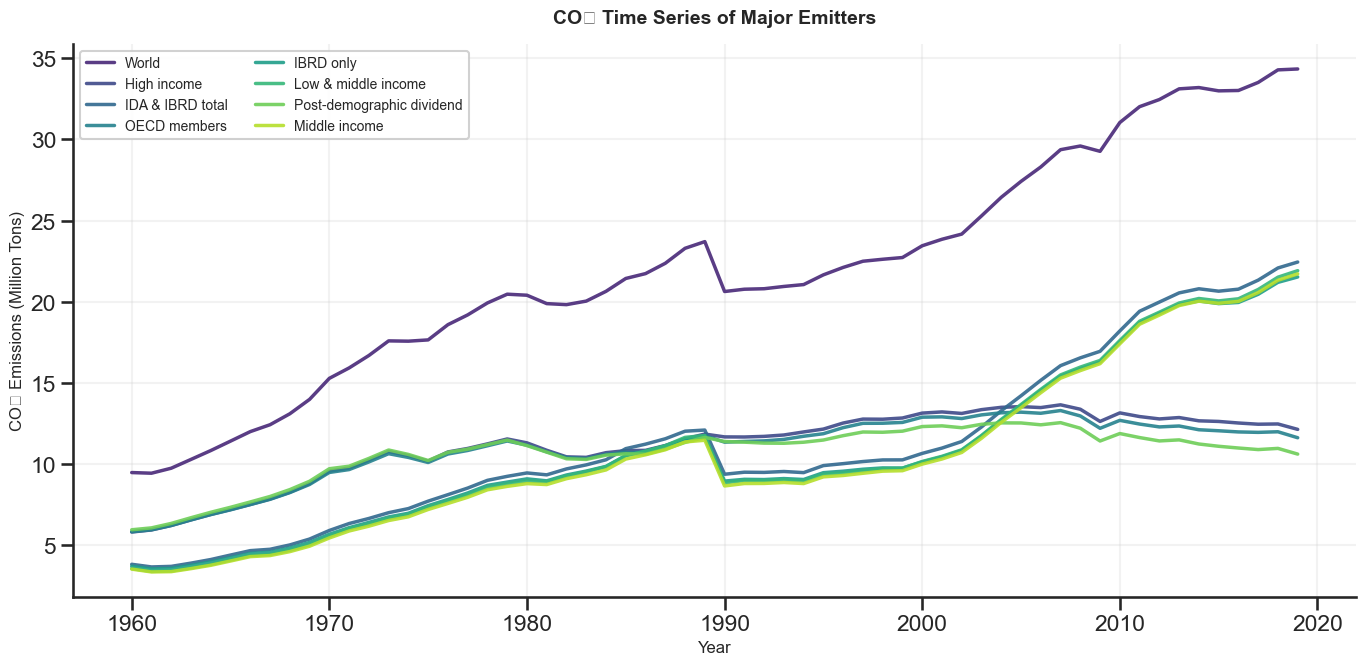

In [131]:
# 图6: CO2时间序列折线图
if df_co2 is None or df_co2.empty:
    pass
else:
    # 准备数据：选择主要排放国
    top_countries = df_co2.groupby('country')['co2_emission'].sum().nlargest(8).index.tolist()
    df_top = df_co2[df_co2['country'].isin(top_countries)].copy()
    
    # 按年份和国家聚合
    df_grouped = df_top.groupby(['year', 'country'])['co2_emission'].sum().reset_index()
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # 使用 viridis 配色
    palette = sns.color_palette("viridis", n_colors=len(top_countries))
    
    for i, country in enumerate(top_countries):
        df_c = df_grouped[df_grouped['country'] == country]
        ax.plot(df_c['year'], df_c['co2_emission'] / 1e6, 
               linewidth=2.5, label=country, color=palette[i], alpha=0.9)
    
    ax.set_xlabel('Year', fontsize=12, weight='medium')
    ax.set_ylabel('CO₂ Emissions (Million Tons)', fontsize=12, weight='medium')
    ax.set_title('CO₂ Time Series of Major Emitters', 
                fontsize=14, weight='bold', pad=15)
    
    ax.legend(loc='upper left', fontsize=10, frameon=True, 
             framealpha=0.9, ncol=2)
    ax.grid(True, alpha=0.25)
    sns.despine()
    
    plt.tight_layout()
    plt.show()


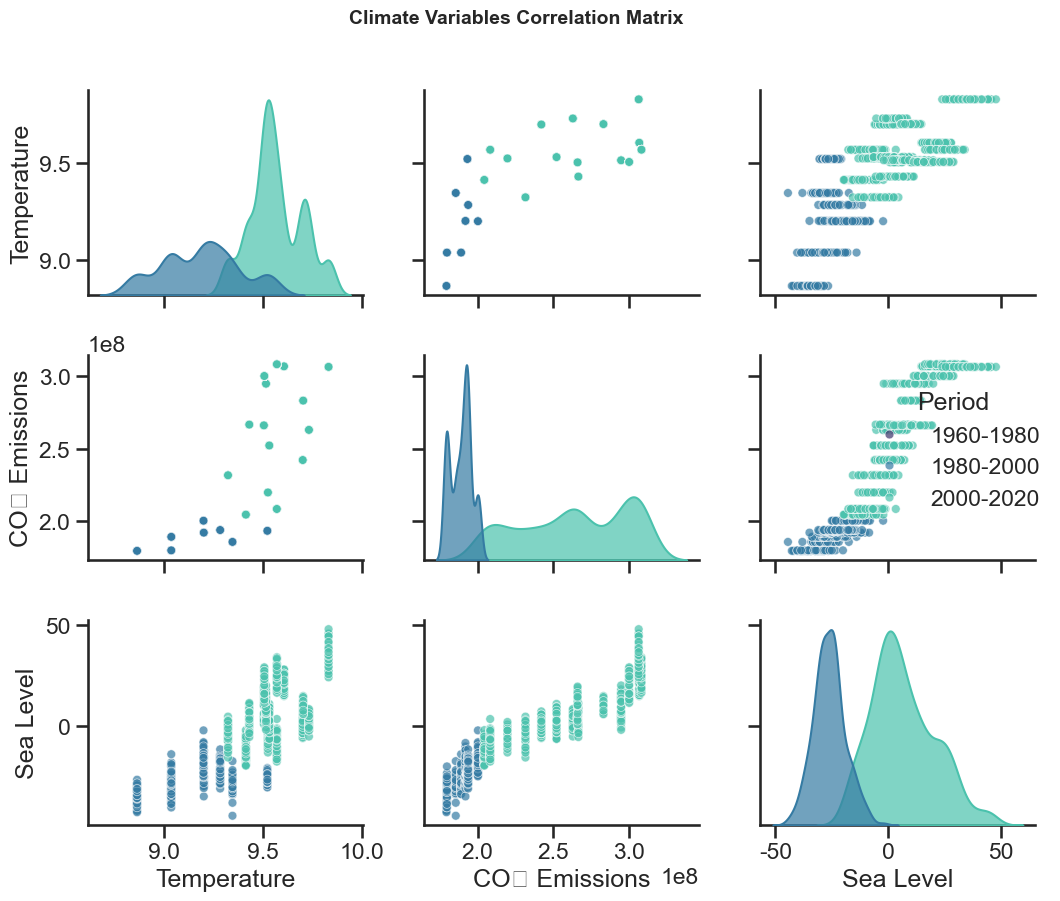

In [132]:
# 图7: PairPlot相关矩阵
# 数据准备
df_temp_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean'
}).reset_index()

df_combined = df_temp_yearly.copy()

if df_co2 is not None and not df_co2.empty:
    df_co2_yearly = df_co2.groupby('year')['co2_emission'].sum().reset_index()
    df_combined = df_combined.merge(df_co2_yearly, on='year', how='left')

if df_sea_level is not None and not df_sea_level.empty:
    df_combined = df_combined.merge(df_sea_level[['year', 'sea_level']], 
                                   on='year', how='left')

df_combined = df_combined.dropna()
df_combined['Period'] = pd.cut(df_combined['year'], 
                            bins=[1960, 1980, 2000, 2020],
                            labels=['1960-1980', '1980-2000', '2000-2020'])

# 重命名列（英文）
df_combined = df_combined.rename(columns={
    'LandAverageTemperature': 'Temperature',
    'co2_emission': 'CO₂ Emissions',
    'sea_level': 'Sea Level'
})

plot_vars = ['Temperature', 'CO₂ Emissions', 'Sea Level']
plot_vars = [v for v in plot_vars if v in df_combined.columns]

if len(plot_vars) >= 2:
    # 绘制 PairPlot - 使用 mako 配色
    g = sns.pairplot(df_combined[plot_vars + ['Period']], hue='Period',
                    palette='mako', diag_kind='kde',
                    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'white', 'linewidth': 0.5},
                    diag_kws={'alpha': 0.7},
                    height=3, aspect=1)
    
    g.fig.suptitle('Climate Variables Correlation Matrix', fontsize=14, weight='bold', y=1.01)
    
    plt.tight_layout()
    plt.show()


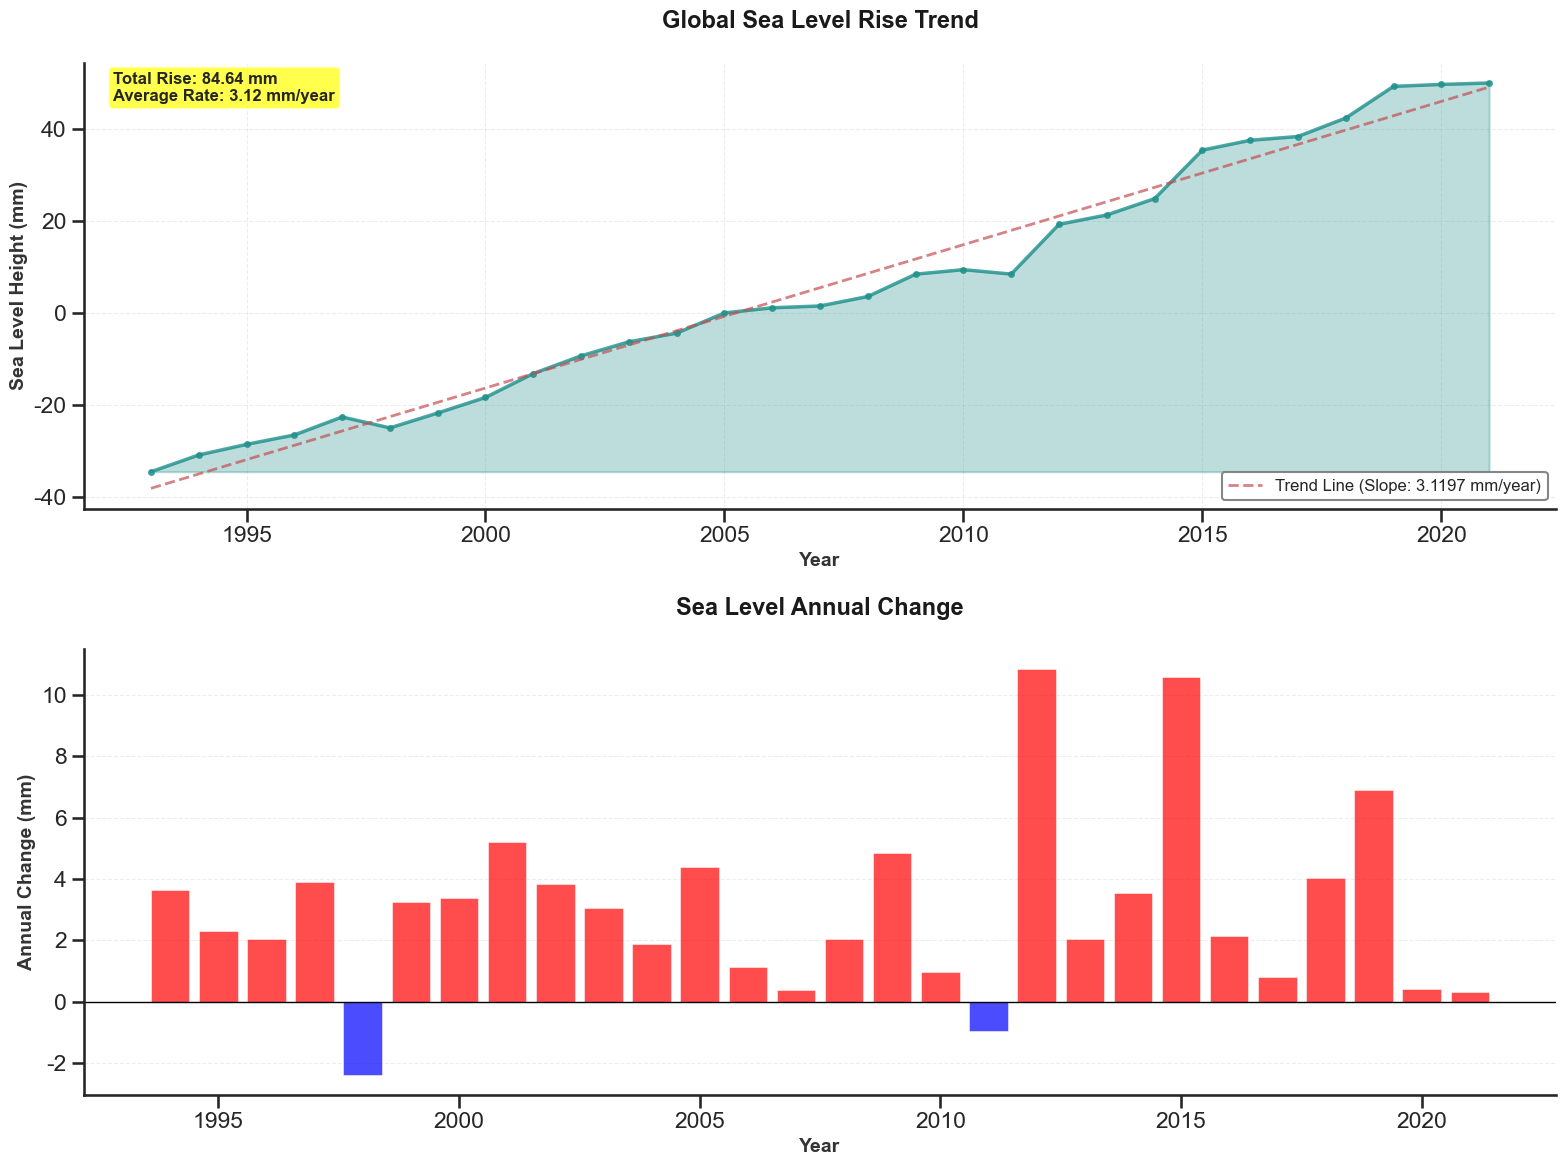

In [133]:
# 图8: 海平面趋势
if df_sea_level is None or df_sea_level.empty:
    pass
else:
    # 找到海平面列（data_loader已经重命名为sea_level）
    if 'sea_level' in df_sea_level.columns:
        sea_level_col = 'sea_level'
    else:
        # 如果没有重命名，尝试查找原始列
        sea_level_col = None
        for col in df_sea_level.columns:
            if 'sea' in col.lower() or 'level' in col.lower() or 'gmsl' in col.lower():
                sea_level_col = col
                break
    
    if sea_level_col is None:
        pass
    else:
        # 按年份聚合
        df_yearly = df_sea_level.groupby('year')[sea_level_col].mean().reset_index()
        df_yearly = df_yearly.dropna()
        df_yearly = df_yearly.sort_values('year')
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
        
        # 子图1：海平面趋势线图
        viridis_colors = sns.color_palette("viridis", 1)
        ax1.plot(df_yearly['year'], df_yearly[sea_level_col],
                linewidth=2.5, color=viridis_colors[0], marker='o', markersize=4, alpha=0.8)
        
        # 添加趋势线
        z = np.polyfit(df_yearly['year'], df_yearly[sea_level_col], 1)
        p = np.poly1d(z)
        ax1.plot(df_yearly['year'], p(df_yearly['year']), 
               'r--', linewidth=2, label=f'Trend Line (Slope: {z[0]:.4f} mm/year)', alpha=0.7)
        
        # 填充区域
        ax1.fill_between(df_yearly['year'], df_yearly[sea_level_col].min(), df_yearly[sea_level_col],
                        alpha=0.3, color=viridis_colors[0])
        
        ax1.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
        ax1.set_ylabel('Sea Level Height (mm)', fontsize=14, fontweight='bold', color='#333333')
        ax1.set_title('Global Sea Level Rise Trend', 
                     fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
        ax1.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
        ax1.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
        # 添加统计信息
        total_rise = df_yearly[sea_level_col].max() - df_yearly[sea_level_col].min()
        avg_rate = z[0]  # mm/year
        ax1.text(0.02, 0.98, 
                f'Total Rise: {total_rise:.2f} mm\nAverage Rate: {avg_rate:.2f} mm/year', 
                transform=ax1.transAxes, fontsize=12, fontweight='bold',
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
        
        # 子图2：年度变化量
        df_yearly['annual_change'] = df_yearly[sea_level_col].diff()
        rocket_colors = sns.color_palette("rocket_r", 1)
        colors = ['red' if x > 0 else 'blue' for x in df_yearly['annual_change']]
        bars = ax2.bar(df_yearly['year'], df_yearly['annual_change'],
                      color=colors, alpha=0.7, edgecolor='white', linewidth=0.5)
        ax2.axhline(0, color='black', linestyle='-', linewidth=1)
        
        ax2.set_xlabel('Year', fontsize=14, fontweight='bold', color='#333333')
        ax2.set_ylabel('Annual Change (mm)', fontsize=14, fontweight='bold', color='#333333')
        ax2.set_title('Sea Level Annual Change', 
                     fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
        ax2.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        
        plt.tight_layout()
        plt.show()


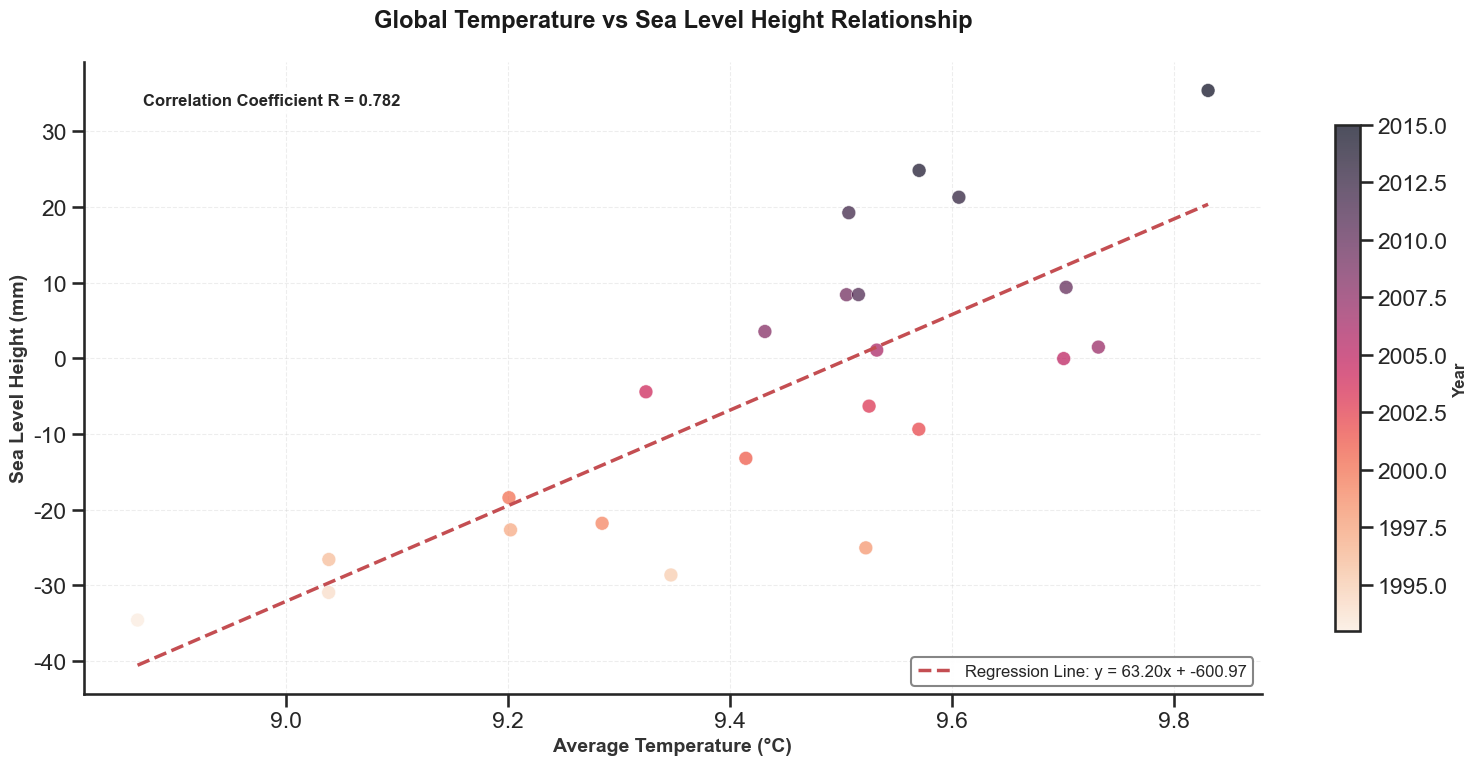

In [134]:
# 图9: 海平面与温度关系
if df_sea_level is None or df_sea_level.empty:
    pass
else:
    # 找到海平面列（data_loader已经重命名为sea_level）
    if 'sea_level' in df_sea_level.columns:
        sea_level_col = 'sea_level'
    else:
        # 如果没有重命名，尝试查找原始列
        sea_level_col = None
        for col in df_sea_level.columns:
            if 'sea' in col.lower() or 'level' in col.lower() or 'gmsl' in col.lower():
                sea_level_col = col
                break
    
    if sea_level_col is None:
        pass
    else:
        # 按年份聚合
        df_sea_yearly = df_sea_level.groupby('year')[sea_level_col].mean().reset_index()
        df_temp_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
        
        # 合并数据
        df_merged = pd.merge(df_sea_yearly, df_temp_yearly, on='year', how='inner')
        df_merged = df_merged.dropna()
        
        if len(df_merged) > 0:
            fig, ax = plt.subplots(figsize=(16, 8))
            
            # 散点图 + 回归线
            ROCKET_R_CMAP = sns.color_palette("rocket_r", as_cmap=True)
            scatter = ax.scatter(df_merged['LandAverageTemperature'], df_merged[sea_level_col],
                               c=df_merged['year'], cmap=ROCKET_R_CMAP,
                               s=100, alpha=0.7, edgecolors='white', linewidth=0.5)
            
            # 添加回归线
            z = np.polyfit(df_merged['LandAverageTemperature'], df_merged[sea_level_col], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df_merged['LandAverageTemperature'].min(), 
                               df_merged['LandAverageTemperature'].max(), 100)
            ax.plot(x_line, p(x_line), 'r--', linewidth=2.5, 
                   label=f'Regression Line: y = {z[0]:.2f}x + {z[1]:.2f}')
            
            # 计算相关系数
            r = np.corrcoef(df_merged['LandAverageTemperature'], df_merged[sea_level_col])[0, 1]
            ax.text(0.05, 0.95, f'Correlation Coefficient R = {r:.3f}', transform=ax.transAxes,
                   fontsize=12, fontweight='bold', verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            ax.set_xlabel('Average Temperature (°C)', fontsize=14, fontweight='bold', color='#333333')
            ax.set_ylabel('Sea Level Height (mm)', fontsize=14, fontweight='bold', color='#333333')
            ax.set_title('Global Temperature vs Sea Level Height Relationship', 
                        fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
            ax.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
            ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
            cbar.set_label('Year', fontsize=12, fontweight='bold', color='#333333')
            
            plt.tight_layout()
            plt.show()


In [135]:
# 所有图表已完成
# others.ipynb包含的图表：
# 1. 04_co2_temp_hexjoint.png - CO2与温度Hex JointPlot
# 2. 主要城市极端高温暴露频率图 - 超过高温阈值的次数（使用cartopy和crest主题，仅显示主要城市）
# 3. 城市高温阈值地理分布图 - 使用cartopy展示高温阈值（90百分位数，使用flare主题），叠加主要城市极端高温暴露频率散点图
# 4. 05_co2_distribution_combo.png - CO2分布组合图
# 5. 06_co2_time_conditional_kde.png - CO2时间条件KDE
# 6. 06_co2_time_series_lines.png - CO2时间序列折线图
# 7. 08_pairplot_pro.png - PairPlot相关矩阵
# 8. 15_sea_level_trend.png - 海平面趋势
# 9. 16_sea_level_vs_temperature.png - 海平面与温度关系
